*   **--------------------------------------------Name: Vanchanagiri Alekhya-----------------------------------------**
*   **----------------------------------------Enrollment Number: MML2025002----------------------------------------**

*   **------------------------------------------GenAI & LLMs Assignment-7
--------------------------------------------**

In [ ]:
!pip install -q sentence-transformers umap-learn hdbscan scikit-learn matplotlib seaborn pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import umap
import hdbscan

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Step 1: Load and Prepare the Data

In [33]:
url = "https://raw.githubusercontent.com/mdsohaib/BBC-News-Classification/master/bbc-text.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("Category distribution:")
print(df["category"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

texts = df["text"].astype(str).tolist()
true_labels = df["category"].tolist()

print("Number of documents:", len(texts))
print("Example article:\n")
print(texts[0][:1000])

Dataset shape: (2225, 2)

Columns: ['category', 'text']

First 5 rows:


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


Category distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Missing values:
category    0
text        0
dtype: int64
Number of documents: 2225
Example article:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and p



In this step, I load the BBC News dataset. The dataset contains two columns:

- category: the true label, which will be kept aside for final evaluation
- text: the raw article text, which will be used for the unsupervised pipeline

The category column is not used during clustering.




#Step-2: Generate Embeddings


In [ ]:
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Embeddings shape: (2225, 384)



Each article was converted into an embedding vector using the all-MiniLM-L6-v2 model.

The result is a matrix where each row corresponds to one article and each column represents one embedding dimension.

Step-4: Reduce Dimensionality & Cluster
---

In [ ]:
def run_umap_hdbscan(embeddings, n_components=5, n_neighbors=15, min_dist=0.0, min_cluster_size=30):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='cosine',
        random_state=42
    )

    reduced = reducer.fit_transform(embeddings)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    cluster_labels = clusterer.fit_predict(reduced)

    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = np.sum(cluster_labels == -1)

    return reduced, cluster_labels, n_clusters, n_noise, reducer, clusterer

In [ ]:
reduced_5d, cluster_labels, n_clusters, n_noise, reducer, clusterer = run_umap_hdbscan(
    embeddings,
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    min_cluster_size=30
)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)
print("Cluster label counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Number of clusters found: 7
Number of noise points: 0
Cluster label counts:
0    905
1    797
2     86
3    149
4    185
5     31
6     72
Name: count, dtype: int64


In [ ]:
results = []

for n_components in [5, 10, 25]:
    for n_neighbors in [10, 15, 30]:
        for min_cluster_size in [15, 30, 50]:
            reduced, labels, n_clusters, n_noise, _, _ = run_umap_hdbscan(
                embeddings,
                n_components=n_components,
                n_neighbors=n_neighbors,
                min_dist=0.0,
                min_cluster_size=min_cluster_size
            )

            results.append({
                "n_components": n_components,
                "n_neighbors": n_neighbors,
                "min_cluster_size": min_cluster_size,
                "clusters_found": n_clusters,
                "noise_points": int(n_noise)
            })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by=["clusters_found", "noise_points"], ascending=[False, True]))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

,n_components,n_neighbors,min_cluster_size,clusters_found,noise_points
18,25,10,15,23,188
0,5,10,15,22,204
12,10,15,15,15,78
9,10,10,15,15,126
21,25,15,15,14,60
6,5,30,15,14,139
3,5,15,15,13,38
15,10,30,15,12,34
19,25,10,30,12,143
10,10,10,30,11,61




The article embeddings are high-dimensional, so I first reduced them using UMAP. Then I applied HDBSCAN to discover clusters in the reduced representation.

I experimented with:
- n_components
- n_neighbors
- min_cluster_size

This helps understand how parameter choices affect the clustering result.

In [ ]:
best_n_components = 5
best_n_neighbors = 15
best_min_cluster_size = 30

reduced_best, best_labels, best_n_clusters, best_n_noise, best_reducer, best_clusterer = run_umap_hdbscan(
    embeddings,
    n_components=best_n_components,
    n_neighbors=best_n_neighbors,
    min_dist=0.0,
    min_cluster_size=best_min_cluster_size
)

print("Chosen configuration:")
print("n_components =", best_n_components)
print("n_neighbors =", best_n_neighbors)
print("min_cluster_size =", best_min_cluster_size)
print("Clusters found =", best_n_clusters)
print("Noise points =", best_n_noise)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Chosen configuration:
n_components = 5
n_neighbors = 15
min_cluster_size = 30
Clusters found = 7
Noise points = 0




HDBSCAN found **7 clusters** and **0 noise articles**.

This can be compared with the known number of **5 original categories** in the BBC dataset.

The model found more than 5 groups, which suggests that it discovered finer subtopics within some categories.

In particular, the original **sport** category seems to have been split into smaller groups such as football, rugby, tennis, athletics, and Olympic-related news.

#Step 4: Topic Interpretation

In [21]:
def compute_ctfidf(texts, labels, top_n=10, stop_words='english'):
    temp_df = pd.DataFrame({"text": texts, "cluster": labels})

    temp_df = temp_df[temp_df["cluster"] != -1].copy()

    docs_per_cluster = temp_df.groupby("cluster", as_index=False).agg({"text": " ".join})

    vectorizer = CountVectorizer(stop_words=stop_words, max_df=0.95, min_df=2)
    X = vectorizer.fit_transform(docs_per_cluster["text"])

    words = np.array(vectorizer.get_feature_names_out())

    tf = X.toarray().astype(float)

    tf = tf / tf.sum(axis=1, keepdims=True)
    m = len(texts)
    df_words = np.sum(X.toarray() > 0, axis=0)
    idf = np.log((m + 1) / (df_words + 1)) + 1

    ctfidf = tf * idf

    topic_words = {}
    for i, cluster_id in enumerate(docs_per_cluster["cluster"]):
        top_indices = ctfidf[i].argsort()[::-1][:top_n]
        topic_words[int(cluster_id)] = words[top_indices].tolist()

    return docs_per_cluster, topic_words

In [22]:
docs_per_cluster, topic_words = compute_ctfidf(texts, best_labels, top_n=10)

print("Top words for each cluster:\n")
for cluster_id, words in topic_words.items():
    print(f"Cluster {cluster_id}: {words}")

Top words for each cluster:

Cluster 0: ['mr', 'government', 'labour', 'election', 'blair', 'party', 'minister', 'uk', 'economy', 'market']
Cluster 1: ['film', 'music', 'mr', 'best', 'mobile', 'uk', 'technology', 'users', 'digital', 'million']
Cluster 2: ['seed', 'australian', 'play', 'second', 'game', 'beat', 'round', 'tennis', 'champion', 'hewitt']
Cluster 3: ['england', 'wales', 'ireland', 'rugby', 'game', 'nations', 'half', 'robinson', 'scotland', 'italy']
Cluster 4: ['club', 'chelsea', 'game', 'arsenal', 'liverpool', 'league', 'manager', 'play', 'manchester', 'boss']
Cluster 5: ['kenteris', 'iaaf', 'drugs', 'doping', 'thanou', 'greek', 'athens', 'tests', 'olympics', 'athletes']
Cluster 6: ['indoor', 'champion', 'best', 'holmes', 'championships', 'athens', 'marathon', 'british', 'mark', 'athletics']


Manual Topic Labels
---

In [23]:
cluster_name_map = {
    0: "Politics and Economy",
    1: "Entertainment and Technology",
    2: "Tennis News",
    3: "Rugby News",
    4: "Football News",
    5: "Olympic Doping Controversy",
    6: "Athletics News"
}



I extracted the top words for each cluster and used them to assign human-readable topic labels. The discovered topics were:

- Politics and Economy
- Entertainment and Technology
- Tennis News
- Rugby News
- Football News
- Olympic Doping Controversy
- Athletics News

These topic labels were based on the dominant words appearing in each cluster.

In [24]:
topic_summary = []

for cluster_id, words in topic_words.items():
    topic_summary.append({
        "Cluster": cluster_id,
        "Top Words": ", ".join(words),
        "Assigned Label": cluster_name_map.get(cluster_id, "Unknown")
    })

topic_summary_df = pd.DataFrame(topic_summary).sort_values("Cluster")
display(topic_summary_df)

,Cluster,Top Words,Assigned Label
0,0,"mr, government, labour, election, blair, party...",Politics and Economy
1,1,"film, music, mr, best, mobile, uk, technology,...",Entertainment and Technology
2,2,"seed, australian, play, second, game, beat, ro...",Tennis News
3,3,"england, wales, ireland, rugby, game, nations,...",Rugby News
4,4,"club, chelsea, game, arsenal, liverpool, leagu...",Football News
5,5,"kenteris, iaaf, drugs, doping, thanou, greek, ...",Olympic Doping Controversy
6,6,"indoor, champion, best, holmes, championships,...",Athletics News


#Step 5: Analysis and Reflection

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


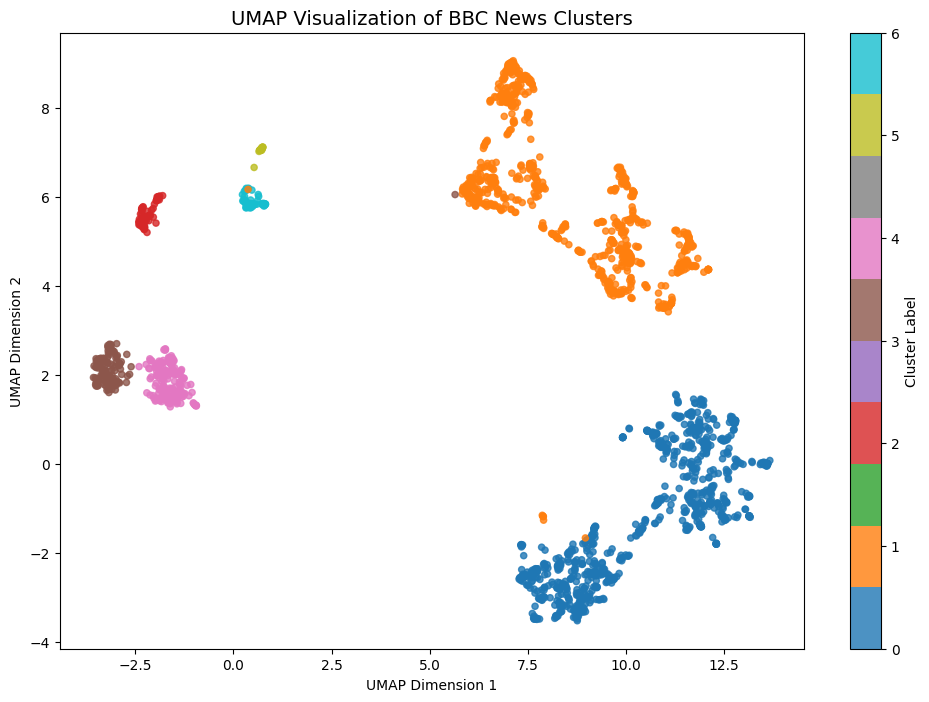

In [32]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=best_n_neighbors,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

reduced_2d = umap_2d.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    reduced_2d[:, 0],
    reduced_2d[:, 1],
    c=best_labels,
    cmap='tab10',
    s=20,
    alpha=0.8
)

plt.title("UMAP Visualization of BBC News Clusters", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster Label")
plt.show()

Comparing Clusters with the Original Categories
---

In [26]:
eval_df = pd.DataFrame({
    "true_category": true_labels,
    "cluster": best_labels
})

display(pd.crosstab(eval_df["cluster"], eval_df["true_category"]))

true_category,business,entertainment,politics,sport,tech
cluster,,,,,
0,485,3,401,0,16
1,17,379,16,1,384
2,0,1,0,85,0
3,0,1,0,147,1
4,8,0,0,177,0
5,0,0,0,31,0
6,0,2,0,70,0




Created a cross-tabulation between the cluster labels and the original category labels.

This makes it easier to see whether the discovered clusters correspond well to the actual categories in the BBC dataset.

In [27]:
noise_df = df[best_labels == -1].copy()
noise_df["cluster"] = best_labels[best_labels == -1]

print("Number of noise articles:", len(noise_df))
display(noise_df[["category", "text"]].head(10))

Number of noise articles: 0


,category,text


In [28]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
df["cluster"] = best_labels

print("Average text length of all documents:", round(df["text_length"].mean(), 2))
print("Average text length of noise documents:", round(df[df["cluster"] == -1]["text_length"].mean(), 2))

Average text length of all documents: 390.3
Average text length of noise documents: nan


### Example Articles in Each Cluster

In [29]:
clustered_df = df.copy()
clustered_df["cluster"] = best_labels

for cluster_id in sorted(clustered_df["cluster"].unique()):
    print("=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)

    sample_rows = clustered_df[clustered_df["cluster"] == cluster_id][["category", "text"]].head(3)

    for idx, row in sample_rows.iterrows():
        print(f"\nTrue category: {row['category']}")
        print(f"Text preview: {row['text'][:500]}")
        print("-" * 80)

CLUSTER 0

True category: business
Text preview: worldcom boss  left books alone  former worldcom boss bernie ebbers  who is accused of overseeing an $11bn (£5.8bn) fraud  never made accounting decisions  a witness has told jurors.  david myers made the comments under questioning by defence lawyers who have been arguing that mr ebbers was not responsible for worldcom s problems. the phone company collapsed in 2002 and prosecutors claim that losses were hidden to protect the firm s shares. mr myers has already pleaded guilty to fraud and is ass
--------------------------------------------------------------------------------

True category: politics
Text preview: howard hits back at mongrel jibe michael howard has said a claim by peter hain that the tory leader is acting like an  attack mongrel  shows labour is  rattled  by the opposition.  in an upbeat speech to his party s spring conference in brighton  he said labour s campaigning tactics proved the tories were hitting home. mr hain m



I examined a few sample articles from every cluster to see what kind of documents were grouped together. This gave a clearer idea of whether the clusters were meaningful and whether they matched the hidden original categories.

Report:
---


The 2D UMAP visualization showed that many of the news articles formed fairly clear groups in the reduced space. This means that the sentence embeddings were able to capture the meaning of the articles really well.  

Articles discussing similar topics were placed closer together, while articles on different topics were placed farther apart. Thi means the embedding model was not just looking at individual words, but also capturing the overall semantic content of each article.

When I compared the discovered clusters with the original hidden category labels, I found that the clustering matched the true categories quite well overall.

However, the model did not produce exactly 5 clusters, which is the number of original BBC categories. Instead, it found 7 clusters.

This happened because the model identified finer structure inside some of the broad categories.

* Example is the **sport** category. Rather than treating all sports articles as one single group, the unsupervised method separated them into more specific themes such as football, rugby, tennis, athletics, and Olympic doping-related news. This shows that the clustering was able to discover subtopics that were more detailed than the original human-assigned categories.




**Observations of Noise articles:**


Another  observation is that HDBSCAN produced **0 noise articles** in the final chosen setting. This means that every article was assigned to one of the clusters, and none were left out as outliers. This is acceptable and indicates that, under this parameter setting, the clustering structure was strong enough to group all articles somewhere. At the same time, this does not mean the clustering is automatically perfect.

A result with zero noise can still contain clusters that are broad, overlapping, or split in ways that differ from the original labels. So this result should be interpreted together with the keyword analysis, visualization, and comparison with the true categories.




**Strengths and weaknesses of this unsupervised approach for organizing a news archive**


Overall, this experiment shows that the unsupervised pipeline is very useful for exploring and organizing a large collection of text documents without needing labeled data.



*   One major strength of this approach is that it can automatically reveal hidden themes and even uncover smaller subtopics within broad categories. This makes it especially useful when working with large text archives where manual labeling would be difficult or time-consuming.



*   At the same time, the approach also has some limitations. The final
clustering result depends quite a lot on parameter choices such as the number of UMAP dimensions, the number of neighbors, and the HDBSCAN minimum cluster size.
*   Small changes in these settings can lead to a different number of clusters or a different amount of noise
*   Also, unsupervised clusters do not always match the original human-defined labels exactly, because the algorithm may discover patterns that are statistically meaningful but not identical to the categories chosen by people.


Even with these limitations, the overall results were strong and showed that this method is effective for discovering structure in a news archive.